# Residual vs fixed $E$ — one profile per cohort

Fit the scaling law parameters to each cohort while holding E fixed for many different values of E

In [1]:
import os, sys, time

# Repo root on the path (for `nano_llama` and `scaling_law`), from either cwd.
_HERE = os.getcwd()
for _cand in (_HERE, os.path.dirname(_HERE)):
    if os.path.isdir(os.path.join(_cand, "nano_llama")) and _cand not in sys.path:
        sys.path.insert(0, _cand)
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
plt.style.use("default")
pd.set_option("display.width", 220)

import scaling_law as est
from scaling_law import data_loading as dl


PROCESSED_DIR = "/home/trevor/fht_summary_data/raw_loss_data"
K = None
MAX_P = None

SCREEN = dict(
    max_ceiling_frac=1.0,
    min_ne_frac=0.5,
    min_tpp=5,
)



FIX_ALPHA2 = 0.0
N0, D0 = est.N0_DEFAULT, est.D0_DEFAULT      # the pivots a and b are reported at (a gauge, not a fit)

# ---- THE PROFILE ITSELF ----
E_LO, E_HI, E_STEP = 0.0, 2.3, 0.05          # the fixed-E grid, clipped below each cohort's min L
N_JOBS = -1                   #  -- -1 takes all cores
# ==========================================================================

cohorts = dl.load_matched_results(PROCESSED_DIR, k=K)
k_used = float(cohorts[next(iter(cohorts))][0].k_train)
if MAX_P is not None:
    cohorts = {q: v for q, v in cohorts.items() if q <= MAX_P}
cohorts, filt = dl.filter_cohorts(cohorts, **SCREEN)
dl.print_filter_report(filt, **SCREEN)

arrs = {}
for p_ in sorted(cohorts):
    a_ = dl.eval_cohort_arrays(cohorts[p_])
    a_["eval_se"] = np.array([r.eval_se for r in cohorts[p_]], dtype=float)
    arrs[p_] = a_
ps = sorted(arrs)
colors = plt.cm.viridis(np.linspace(0.08, 0.94, len(ps)))


E_CAP = {p: float(arrs[p]["L"].min()) for p in ps}
GRID = np.round(np.arange(E_LO, E_HI + 0.5 * E_STEP, E_STEP), 6)


run filter: keep L < 1 ln(vocab), tokens/total-param >= 5, non-emb params >= 0.5  ->  dropped 1421 run(s) across 17 cohort(s)  (1081 by min_ne_frac, 340 by min_tpp)
   cohort   kept  dropped                     TPP range               L max         ne_frac min
-----------------------------------------------------------------------------------------------
        0    108       84                2-320 -> 5-320      7.144 -> 4.676      0.092 -> 0.538
    0.005    108       83                2-320 -> 5-320      7.159 -> 4.706      0.092 -> 0.538
     0.01    108       84                2-320 -> 5-320      7.145 -> 4.703      0.092 -> 0.538
    0.015    108       83                2-320 -> 5-320      7.169 -> 4.740      0.092 -> 0.538
     0.02    106       84                2-320 -> 5-320      7.173 -> 4.750      0.092 -> 0.538
    0.025    108       84                2-320 -> 5-320      7.152 -> 4.747      0.092 -> 0.538
     0.03    108       84                2-320 -> 5-320      7.174 

## 1. Compute the profiles

One fit per (cohort, $E$), plus each cohort's free-$E$ fit as the reference. The free-$E$ objective is
by construction the **minimum of that cohort's profile** — fitting $E$ can never do worse than pinning
it — so every curve below is plotted as *how much worse than that cohort's own best*, in percent. That
makes 17 curves on wildly different objective scales directly comparable.

In [2]:
def one(p, fe):
    """One (cohort, pinned E) refit -> a row. Every OTHER switch comes from cell 1, so a profile is
    always a slice through one surface family and one screen."""
    a = arrs[p]
    f = est.fit(a["N"], a["D"], a["L"], fix_E=fe, fix_alpha2=FIX_ALPHA2, N0=N0, D0=D0)
    pred = f.predict(a["N"], a["D"])
    r = np.log(pred) - np.log(a["L"])
    return dict(p_train=p, fix_E=(np.nan if fe is None else float(fe)), free_E=(fe is None),
                E=f.E, a=f.a, alpha1=f.alpha1, alpha2=f.alpha2, b=f.b, beta1=f.beta1,
                amp_N=f.amp_N, amp_D=f.amp_D, objective=f.objective,
                rmse_log=float(np.sqrt(np.mean(r ** 2))),
                rmse_nats=float(np.sqrt(np.mean((pred - a["L"]) ** 2))))

jobs = [(p, fe) for p in ps for fe in list(GRID[GRID < E_CAP[p]]) + [None]]
t0 = time.time()
df = pd.DataFrame(Parallel(n_jobs=N_JOBS)(delayed(one)(p, fe) for p, fe in jobs))
print(f"{len(df)} fits in {time.time() - t0:.1f}s")

prof = df[~df.free_E].sort_values(["p_train", "fix_E"]).reset_index(drop=True)
free = df[df.free_E].set_index("p_train")

# excess over each cohort's OWN minimum (its free-E fit), in percent
prof["obj_min"] = prof["p_train"].map(free["objective"])
prof["excess_pct"] = 100.0 * (prof["objective"] / prof["obj_min"] - 1.0)
bad = prof[prof.excess_pct < -1e-6]
print(f"points below the free-E minimum (should be none): {len(bad)}")
print("\nfree-E reference per cohort (the bottom of each profile):")
print(free[["E", "a", "alpha1", "alpha2", "b", "beta1", "objective", "rmse_log"]]
      .to_string(float_format=lambda v: f"{v:.4g}"))

814 fits in 18.0s
points below the free-E minimum (should be none): 0

free-E reference per cohort (the bottom of each profile):
                E      a  alpha1  alpha2      b  beta1  objective  rmse_log
p_train                                                                    
0.000       1.535 0.1547  0.1849       0 0.7445 0.4285  0.0005242  0.006915
0.005       1.389  0.297  0.1668       0 0.7264 0.4219  0.0005764  0.007317
0.010       1.399 0.3002   0.168       0 0.7123 0.4143  0.0005988  0.007809
0.015       1.119 0.5121  0.1367       0 0.7265 0.4295  0.0004979  0.006863
0.020        1.22 0.4597  0.1457       0 0.7116 0.4249  0.0005691  0.007532
0.025       1.269 0.4209  0.1544       0 0.6954 0.4016  0.0005314  0.007113
0.030      0.6415   0.78  0.1047       0 0.7202 0.4157  0.0004667  0.006572
0.035        1.06 0.5702  0.1333       0 0.7008 0.4079  0.0005109  0.006779
0.040      0.7835 0.7246  0.1121       0 0.7226 0.4195  0.0004885  0.006565
0.060      0.2011 0.9788 0.08722   

## 2. The profiles, one panel per cohort

Each panel is a single cohort: how much worse its fit gets as the floor is pinned away from that
cohort's own optimum. The dashed vertical line is its free-$E$ $\hat{E}$; the shaded band is every $E$
within **1%** of the best objective — a descriptive "these all fit about as well" range, not a
confidence interval (the objective is a near-L1 Huber sum, so there is no $\chi^2$ calibration to
appeal to).

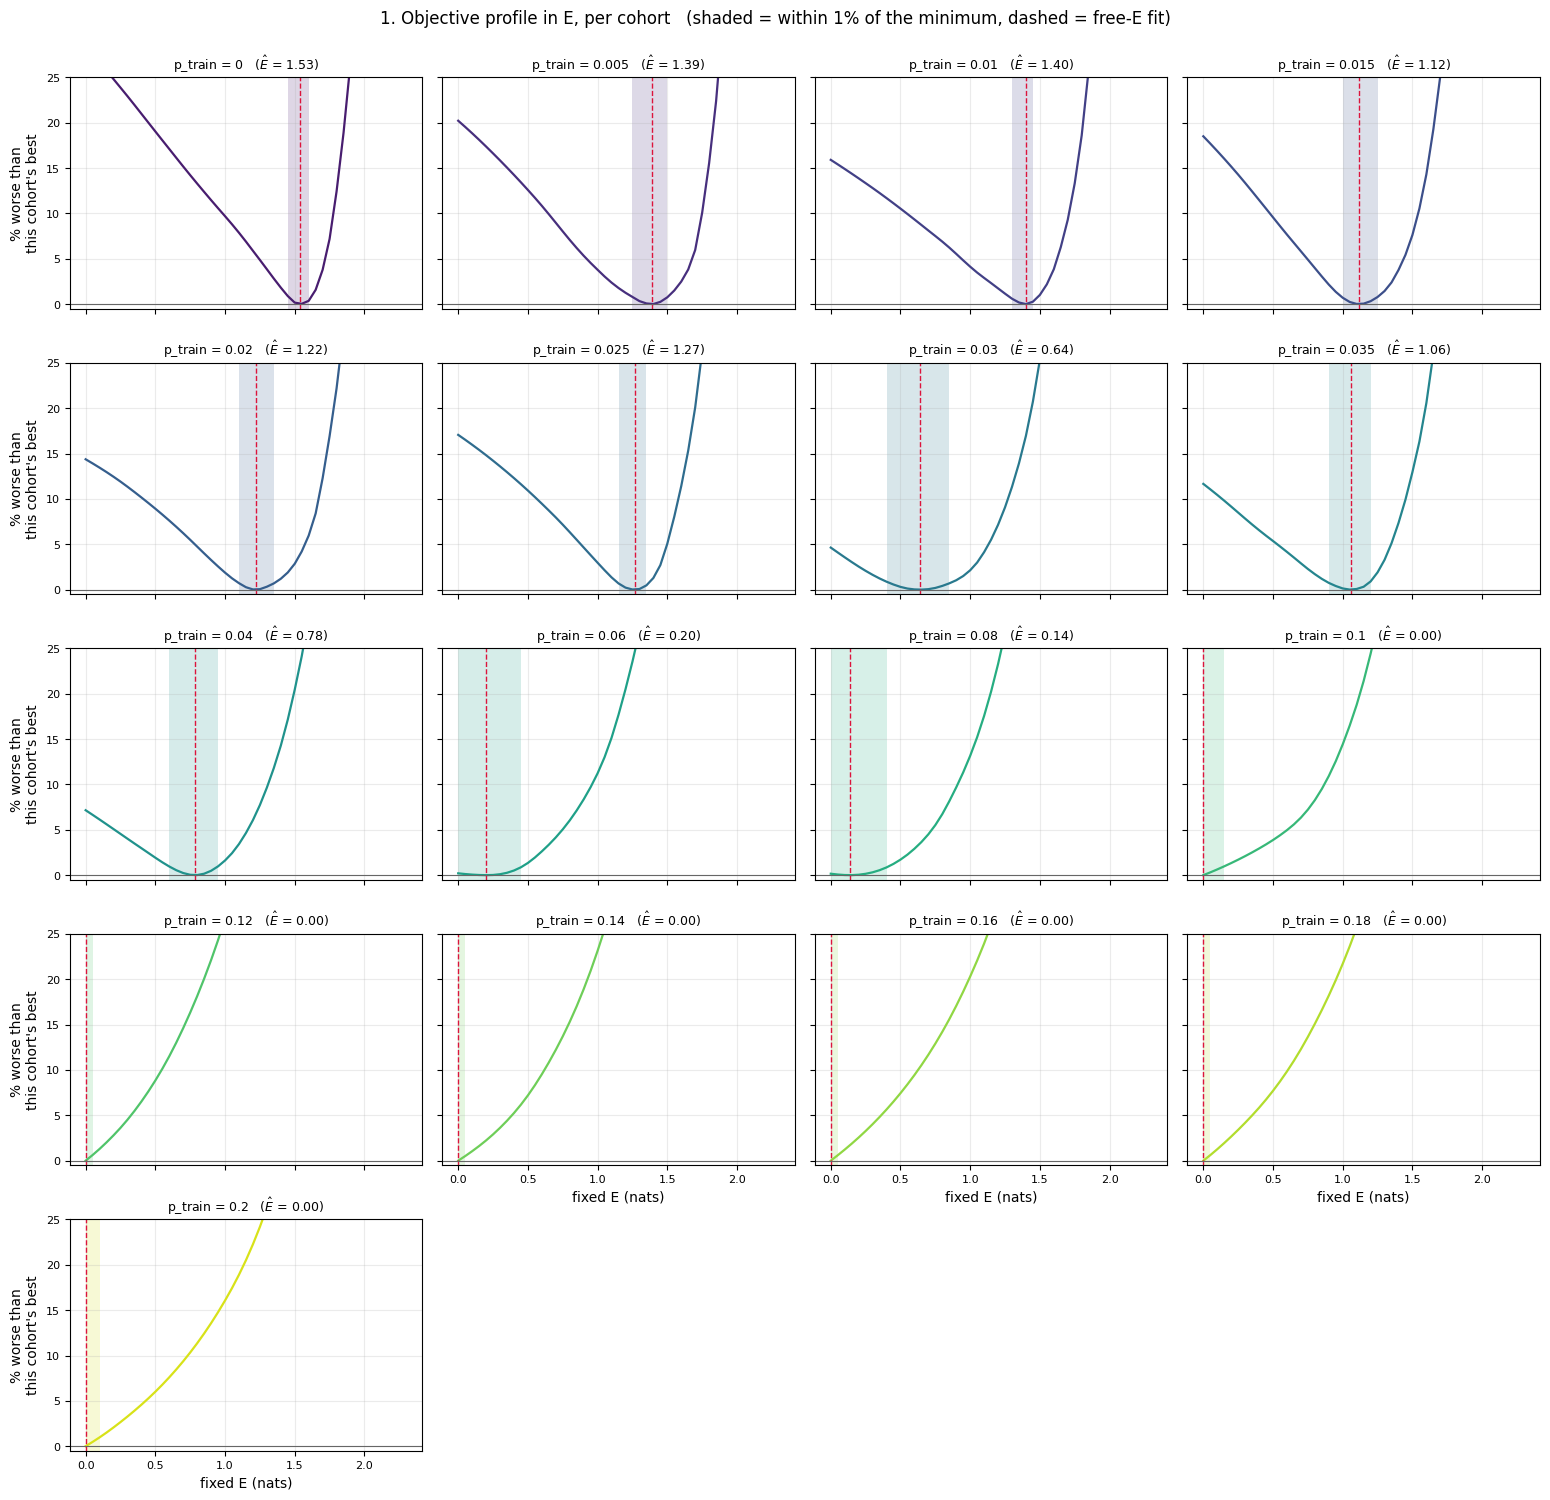

In [3]:
%matplotlib inline

TOL = 1.0                                   # % above the cohort's own minimum
ncols = 4
nrows = int(np.ceil(len(ps) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.9 * ncols, 3.0 * nrows), sharex=True, sharey=True)
band = {}
for axi, (p, c) in zip(axes.flat, zip(ps, colors)):
    s = prof[prof.p_train == p]
    axi.plot(s["fix_E"], s["excess_pct"], "-", lw=1.6, color=c)
    ok = s[s.excess_pct <= TOL]["fix_E"]
    band[p] = (float(ok.min()), float(ok.max())) if len(ok) else (np.nan, np.nan)
    if len(ok):
        axi.axvspan(band[p][0], band[p][1], color=c, alpha=0.18, lw=0)
    axi.axvline(free.loc[p, "E"], ls="--", lw=1, color="crimson")
    axi.axhline(0, lw=0.8, color="0.4")
    axi.set_title(f"p_train = {p:g}   ($\\hat{{E}}$ = {free.loc[p, 'E']:.2f})", fontsize=9)
    axi.grid(alpha=0.25)
    axi.tick_params(labelsize=8)
axes.flat[0].set_ylim(-0.5, 25)
for axi in axes.flat[len(ps):]:
    axi.axis("off")
for col in range(ncols):
    rows = [r for r in range(nrows) if r * ncols + col < len(ps)]
    if rows:
        axes[rows[-1], col].set_xlabel("fixed E (nats)")
        axes[rows[-1], col].tick_params(labelbottom=True)
for axi in axes[:, 0]:
    axi.set_ylabel("% worse than\nthis cohort's best")
fig.suptitle(f"1. Objective profile in E, per cohort   (shaded = within {TOL:g}% of the minimum, "
             "dashed = free-E fit)", y=0.997)
fig.tight_layout()
plt.show()